In [1]:
import sqlite3
import pandas as pd
import plotly.express as px
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
def plotids(selected_ids):
    import numpy as np
    import matplotlib.pyplot as plt
    import tables
    print(f"Selected {len(selected_ids)} points")
    n = min(len(selected_ids), 100)
    cols = 10
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))
    axes = np.array(axes).flat  # handles both 1-row and multi-row cases

    with tables.open_file("mitosis_ps_labels.pytable", "r") as f:
        patches = f.root.patch[selected_ids[:n],::]
        labels = f.root.ps_label[selected_ids[:n]]
        patch_ids = f.root.patch_id[selected_ids[:n]]
        

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(patches[i])
            ax.set_title(f"id:{patch_ids[i]}\nlbl:{labels[i]}", fontsize=6)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
# --- Load coordinates from SpatiaLite ---
conn = sqlite3.connect("coords_embeddings.db")
df  = pd.read_sql("SELECT id, x, y,emb FROM patches", conn)


In [5]:
import tables
with tables.open_file("mitosis_ps_labels.pytable", "r") as f:
    all_labels = f.root.ps_label[:]
    

In [6]:
#----

In [7]:
import os, sqlite_vector
conn.enable_load_extension(True)
so_path = os.path.join(os.path.dirname(sqlite_vector.__file__), "binaries", "vector")
conn.load_extension(so_path)


In [8]:
# -- Initialize the vector. By default, the distance function is L2.
# -- To use a different metric, specify one of the following options:
# -- distance=L1, distance=COSINE, distance=DOT, distance=SQUARED_L2, or distance=HAMMING.
# SELECT vector_init('images', 'embedding', 'type=FLOAT32,dimension=384');
conn.execute("SELECT vector_init('patches', 'emb', 'type=FLOAT32,dimension=16')")

In [9]:
import numpy as np
df["x"] = np.random.rand(len(df))
df["y"] = np.random.rand(len(df))


In [10]:
df["x"]

0       0.536026
1       0.022767
2       0.010408
3       0.227786
4       0.697359
          ...   
6266    0.725873
6267    0.686351
6268    0.803640
6269    0.724496
6270    0.316338
Name: x, Length: 6271, dtype: float64

In [11]:
import plotly.graph_objs as go

fw = go.FigureWidget(data=go.Scatter(
    x=df["x"], y=df["y"],
    mode="markers",
    customdata=df["id"],
))
fw.layout.dragmode = "lasso"

selected_ids = []

def on_select(trace, points, selector):
    selected_ids.clear()
    selected_ids.extend([trace.customdata[i] for i in points.point_inds])
    print(f"Selected {len(selected_ids)} points")

fw.data[0].on_selection(on_select)
fw

FigureWidget({
    'data': [{'customdata': array([   0,    1,    2, ..., 6268, 6269, 6270], shape=(6271,)),
              'mode': 'markers',
              'type': 'scatter',
              'uid': '981e0911-c37a-4472-ba40-e49ea799a944',
              'x': array([0.53602587, 0.02276742, 0.01040769, ..., 0.80364003, 0.72449617,
                          0.31633817], shape=(6271,)),
              'y': array([0.29483257, 0.11237173, 0.76207744, ..., 0.29295177, 0.6094056 ,
                          0.10520612], shape=(6271,))}],
    'layout': {'dragmode': 'lasso', 'template': '...'}
})

In [16]:
len(selected_ids)

47

Selected 47 points


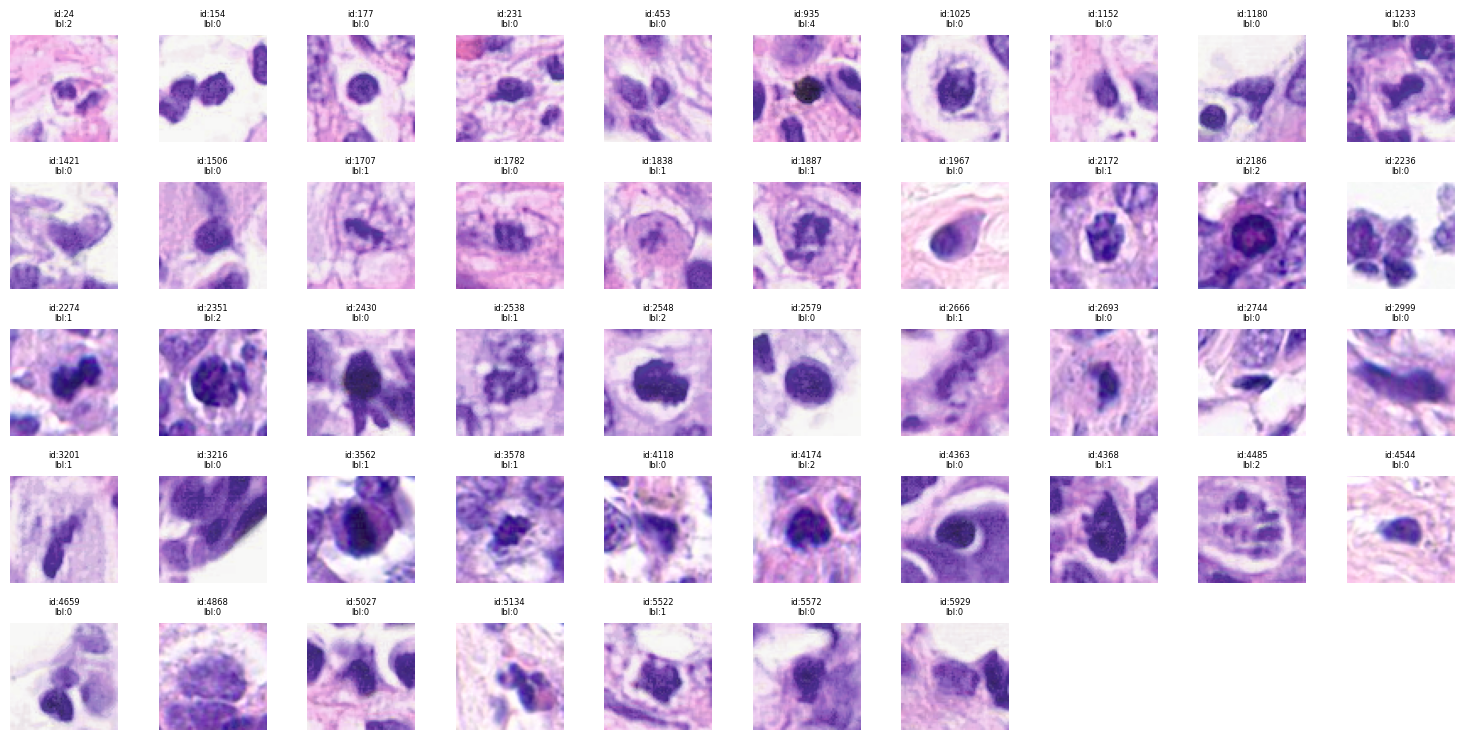

In [ ]:
plotids(selected_ids)


In [ ]:
#--- high dimensional search

In [68]:
%%time
def query_vector(mean_emb):
    query_blob = sqlite3.Binary(mean_emb.tobytes())
    results = conn.execute("""
        SELECT p.id, v.distance
        FROM patches AS p
        JOIN vector_full_scan('patches', 'emb', ?) AS v ON p.id = v.rowid
        ORDER BY v.distance
        LIMIT 100
    """, (query_blob,)).fetchall()
    ids, distances = zip(*results)
    print(results[0:5])
    return list(ids), list(distances)
def query_id(id):
    query_vec = np.frombuffer(df.loc[id, "emb"], dtype=np.float32)
    return query_vector(query_vec)


CPU times: user 29 μs, sys: 0 ns, total: 29 μs
Wall time: 46.5 μs


In [26]:
embs = np.stack([np.frombuffer(e, dtype=np.float32) for e in df.loc[selected_ids, "emb"]])
mean_emb = embs.mean(axis=0)
results = query_vector(mean_emb)

[(598, 0.00657316017895937), (5272, 0.0068197171203792095), (3283, 0.0069509162567555904), (1615, 0.007039960473775864), (2627, 0.007163717411458492)]


In [21]:
# --- quantization --- but would focus on full reprensetations first. be ware, need to check that the results are meaningful  with q=2 + 4 the results were very suboptimal
# #-- seutp quantization (for faster search, with some loss in accuracy)
# conn.execute("SELECT vector_quantize('patches', 'emb', 'qtype=TURBO,qbits=4');")
# ##-- Optional preload quantized version in memory (for a 4x/5x speedup) 
# conn.execute("SELECT vector_quantize_preload('patches', 'emb');")
# %%time
# query_blob = sqlite3.Binary(mean_emb.tobytes())
# results = conn.execute("""
#     SELECT p.id, v.distance
#     FROM patches AS p
#     JOIN vector_quantize_scan('patches', 'emb', ?) AS v ON p.id = v.rowid
#     ORDER BY v.distance
#     LIMIT 100
# """, (query_blob,)).fetchall()

# top_ids = [r[0] for r in results]
# #print(top_ids[:5])
# print(results[0:5])



In [22]:
##sanity check
print(np.frombuffer(df.loc[results[0][0],"emb"],dtype=np.float32))
print(mean_emb)

[-0.220737    0.17042308 -0.28991863  0.28884485  0.16735515  0.2880779
 -0.3075592  -0.16858232 -0.03719855  0.30571845  0.31246787 -0.3184503
 -0.30541164 -0.05924924  0.20371003 -0.29758844]
[-0.22120906  0.17089586 -0.28907937  0.28727072  0.16814068  0.29032463
 -0.30529776 -0.16860776 -0.03455577  0.3043161   0.31120124 -0.3155151
 -0.30402628 -0.06135214  0.20190345 -0.29773805]


Selected 100 points


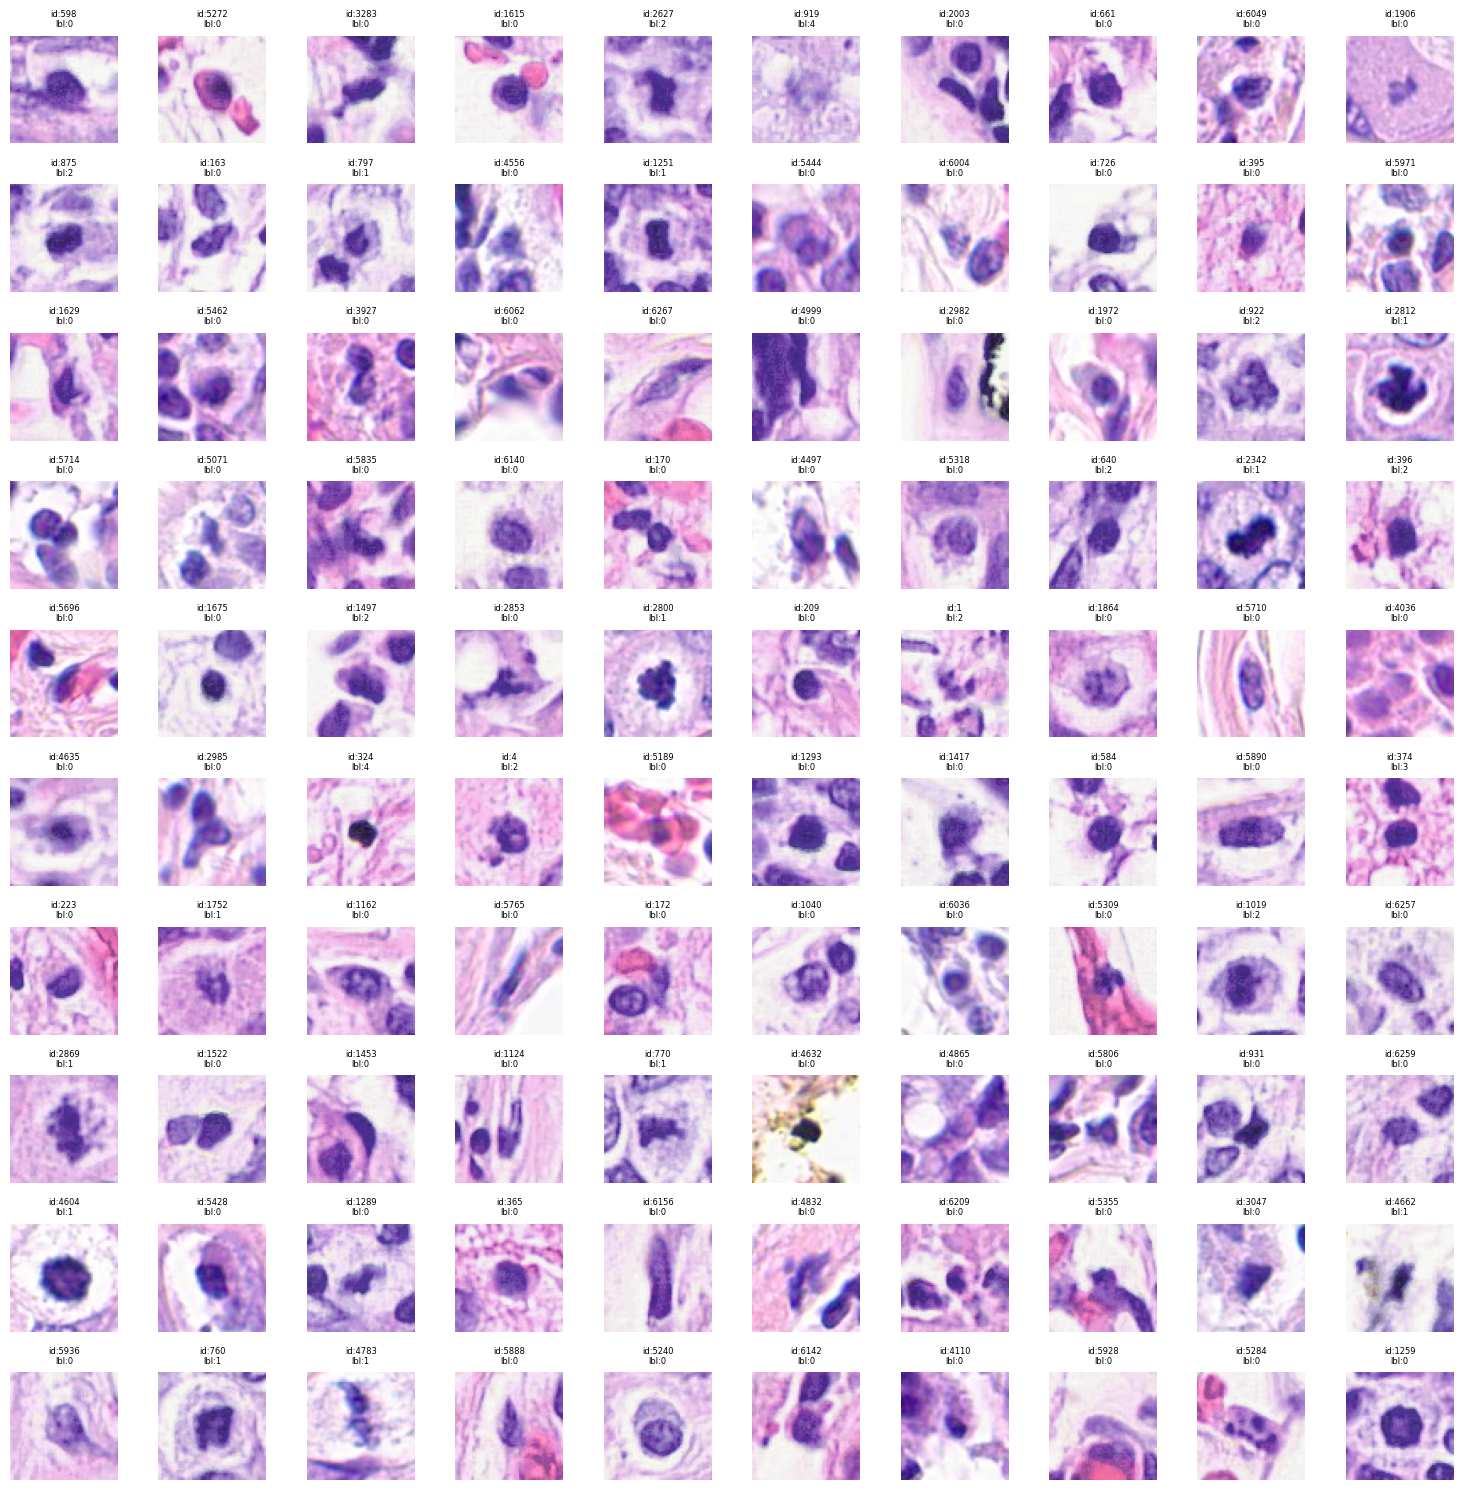

In [23]:
selected_ids_high=[r[0] for r in results]
plotids(selected_ids_high)

Selected 1306 points


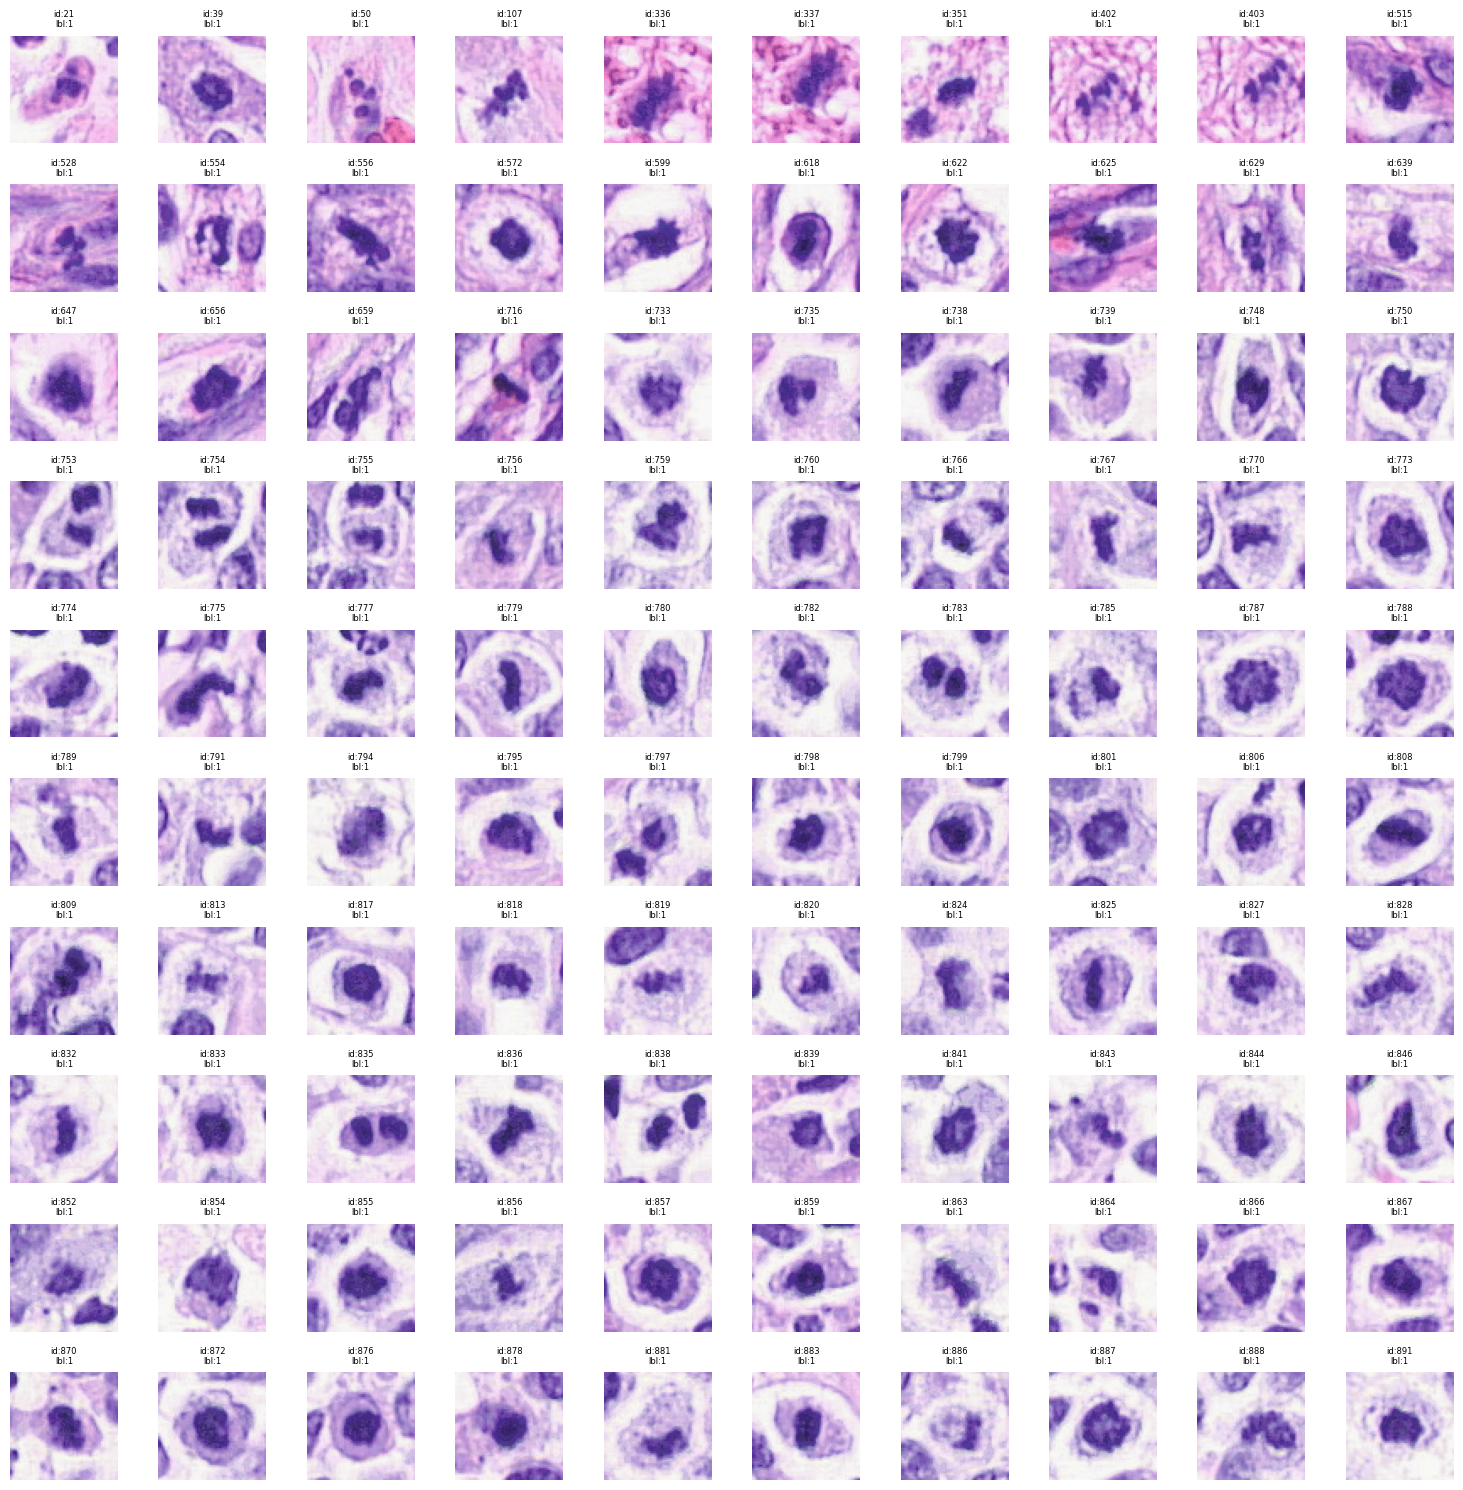

In [24]:
plotids((all_labels==1).nonzero()[0])

[(21, 0.0), (970, 0.0006726019200868905), (1484, 0.0007373348926194012), (5228, 0.0014130319468677044), (693, 0.0014548925682902336)]
[(21, 0.0), (970, 0.0006726019200868905), (1484, 0.0007373348926194012), (5228, 0.0014130319468677044), (693, 0.0014548925682902336)]
Selected 100 points


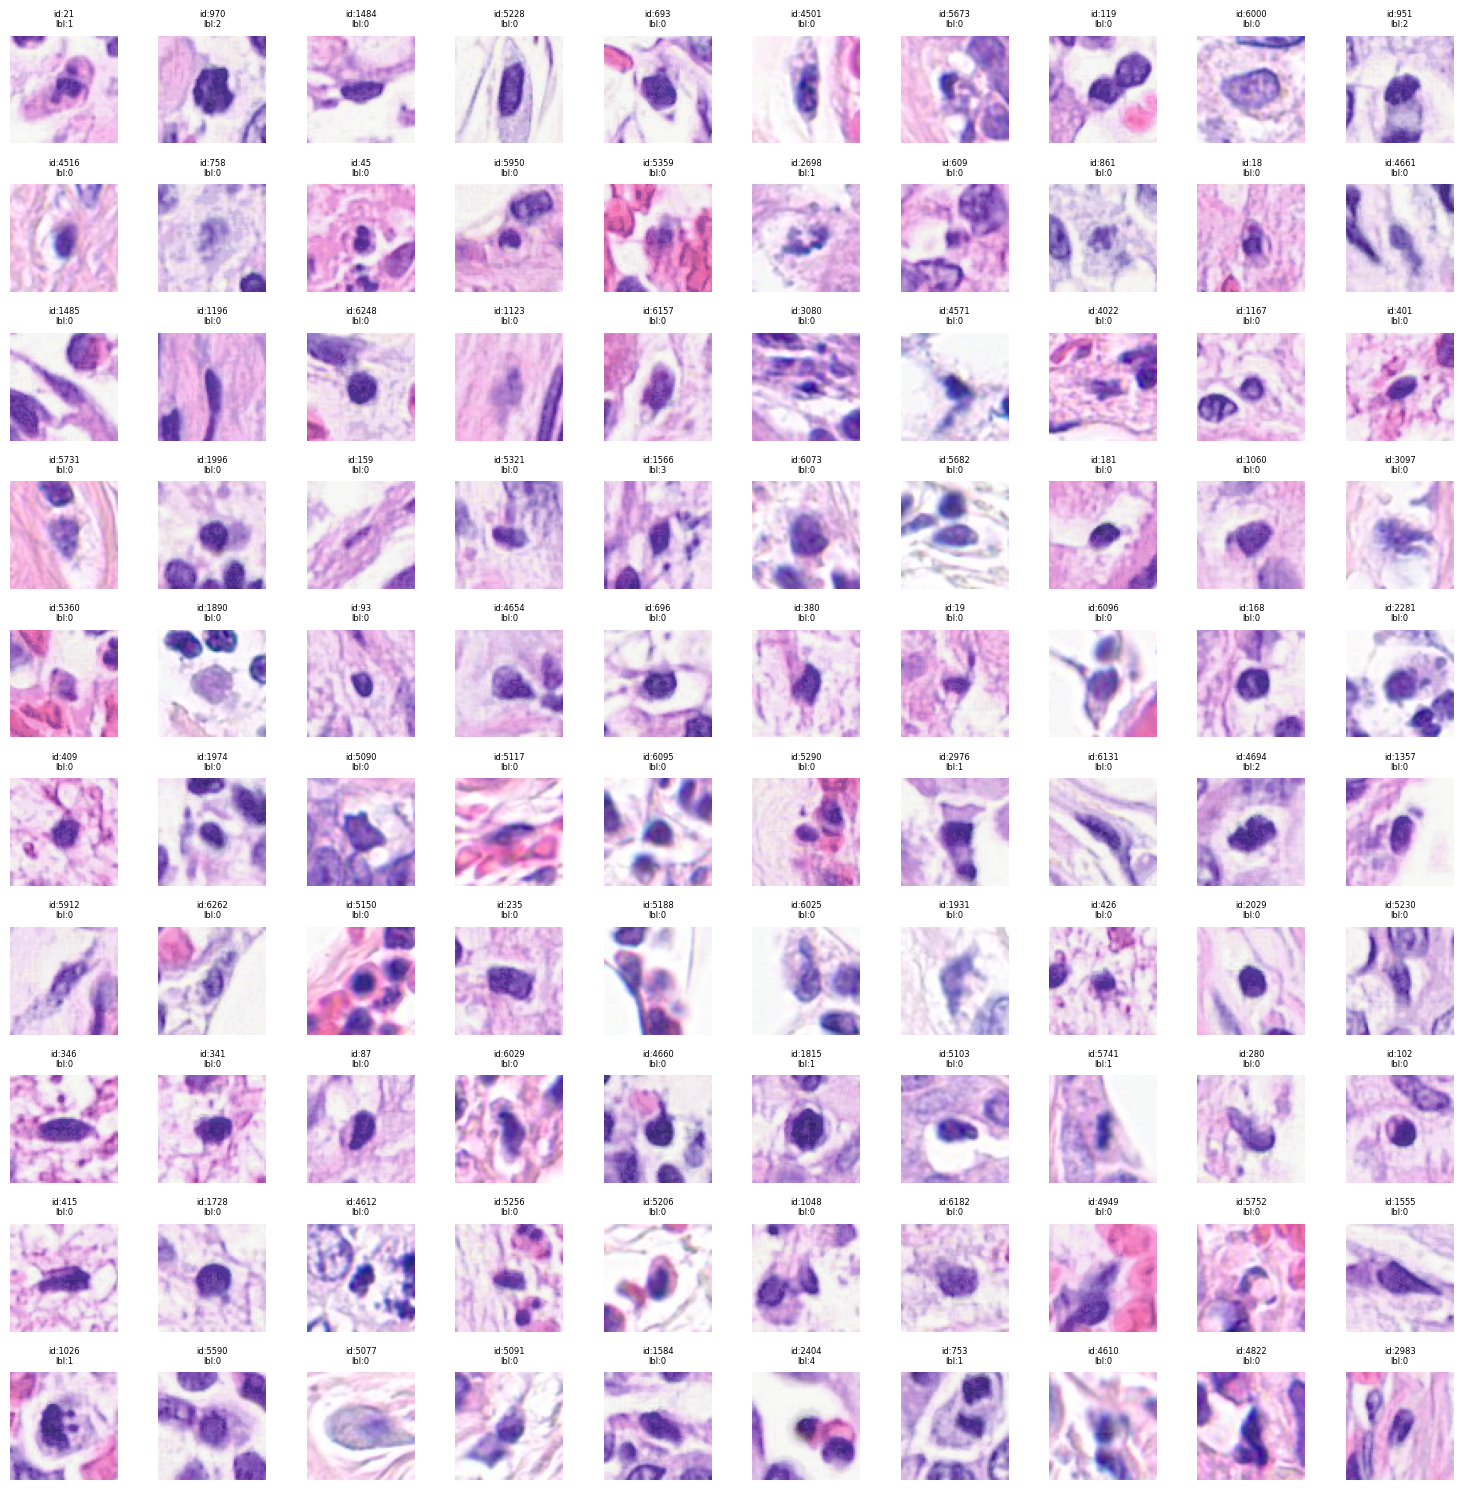

In [69]:
posids=(all_labels==1).nonzero()[0]
res = query_id(posids[0])[0]
plotids(query_id(posids[0])[0])